# AI for Radiologic Image Tasks - *Mastering Artificial Intelligence in Radiology*
## Classification

This notebook compares the Shenzhen and Montgomery chest X-ray datasets using their clinical-reading text files. It extracts each image label from the filename suffix, parses patient sex and age from the text metadata, and plots label, sex, and age distributions across datasets.

## 0. Setup

In [1]:
from pathlib import Path
import re

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.set_option("display.max_colwidth", 120)

SHENZHEN_DIR = Path("/media/felipe/KINGSTON/datasets/shenzhen/ChinaSet_AllFiles")
MONTGOMERY_DIR = Path("/media/felipe/KINGSTON/datasets/NLM-MontgomeryCXRSet/MontgomerySet")

DATASETS = {
    "Shenzhen": {
        "image_dir": SHENZHEN_DIR / "CXR_png",
        "reading_dir": SHENZHEN_DIR / "ClinicalReadings",
    },
    "Montgomery": {
        "image_dir": MONTGOMERY_DIR / "CXR_png",
        "reading_dir": MONTGOMERY_DIR / "ClinicalReadings",
    },
}

for dataset_name, paths in DATASETS.items():
    assert paths["image_dir"].exists(), f"Missing image directory for {dataset_name}: {paths['image_dir']}"
    assert paths["reading_dir"].exists(), f"Missing clinical readings for {dataset_name}: {paths['reading_dir']}"

## 1. Metadata Parsing

In [2]:
def label_from_image_id(image_id: str) -> int:
    suffix = image_id.rsplit("_", 1)[-1]
    if suffix not in {"0", "1"}:
        raise ValueError(f"Expected image id to end with _0 or _1, got {image_id!r}")
    return int(suffix)


def label_name(label: int) -> str:
    return "TB" if label == 1 else "No TB"


def parse_sex(text: str, dataset: str) -> str | None:
    if dataset == "Montgomery":
        match = re.search(r"Patient's\s+Sex:\s*([MFO])\b", text, flags=re.IGNORECASE)
        if match:
            return {"M": "Male", "F": "Female", "O": "Other/Unknown"}[match.group(1).upper()]

    first_line = next((line.strip() for line in text.splitlines() if line.strip()), "")
    line = first_line.lower()

    if re.search(r"\bfemal(?:e)?\b|\bfemale(?=\d)", line):
        return "Female"
    if re.search(r"\bmale\b|\bmale(?=\d)", line):
        return "Male"

    match = re.search(r"\b([MF])\b", first_line, flags=re.IGNORECASE)
    if match:
        return {"M": "Male", "F": "Female"}[match.group(1).upper()]

    return None


def parse_age(text: str, dataset: str) -> float | None:
    if dataset == "Montgomery":
        match = re.search(r"Patient's\s+Age:\s*0*(\d{1,3})\s*Y\b", text, flags=re.IGNORECASE)
        if match:
            return float(match.group(1))

    first_line = next((line.strip() for line in text.splitlines() if line.strip()), "")
    match = re.search(r"(\d{1,3})\s*(?:yrs?|years?|y/o|yo|y)\b", first_line, flags=re.IGNORECASE)
    if match:
        return float(match.group(1))

    match = re.search(r"(\d{1,3})\s*(?:months?|mos?|mo)\b", first_line, flags=re.IGNORECASE)
    if match:
        return round(float(match.group(1)) / 12.0, 2)

    match = re.search(r"(\d{1,3})\s*(?:days?|d)\b", first_line, flags=re.IGNORECASE)
    if match:
        return round(float(match.group(1)) / 365.25, 2)

    match = re.search(r"\b(\d{1,3})\b", first_line)
    if match:
        return float(match.group(1))

    return None

def build_dataset_index(dataset: str, image_dir: Path, reading_dir: Path) -> pd.DataFrame:
    rows = []
    for image_path in sorted(image_dir.glob("*.png")):
        image_id = image_path.stem
        reading_path = reading_dir / f"{image_id}.txt"
        text = reading_path.read_text(errors="replace") if reading_path.exists() else ""
        label = label_from_image_id(image_id)
        rows.append({
            "Dataset": dataset,
            "ImageId": image_id,
            "label": label,
            "label_name": label_name(label),
            "sex": parse_sex(text, dataset) if text else None,
            "age": parse_age(text, dataset) if text else None,
            "reading_first_line": next((line.strip() for line in text.splitlines() if line.strip()), ""),
            "has_reading": reading_path.exists(),
            "image_path": image_path,
            "reading_path": reading_path,
        })
    return pd.DataFrame(rows)


dataset_frames = [
    build_dataset_index(name, paths["image_dir"], paths["reading_dir"])
    for name, paths in DATASETS.items()
]
metadata_df = pd.concat(dataset_frames, ignore_index=True)
metadata_df.head()

,Dataset,ImageId,label,label_name,sex,age,reading_first_line,has_reading,image_path,reading_path
0,Shenzhen,CHNCXR_0001_0,0,No TB,Male,45.0,male 45yrs,True,/media/felipe/KINGSTON/datasets/shenzhen/ChinaSet_AllFiles/CXR_png/CHNCXR_0001_0.png,/media/felipe/KINGSTON/datasets/shenzhen/ChinaSet_AllFiles/ClinicalReadings/CHNCXR_0001_0.txt
1,Shenzhen,CHNCXR_0002_0,0,No TB,Male,63.0,male 63yrs,True,/media/felipe/KINGSTON/datasets/shenzhen/ChinaSet_AllFiles/CXR_png/CHNCXR_0002_0.png,/media/felipe/KINGSTON/datasets/shenzhen/ChinaSet_AllFiles/ClinicalReadings/CHNCXR_0002_0.txt
2,Shenzhen,CHNCXR_0003_0,0,No TB,Female,48.0,female 48yrs,True,/media/felipe/KINGSTON/datasets/shenzhen/ChinaSet_AllFiles/CXR_png/CHNCXR_0003_0.png,/media/felipe/KINGSTON/datasets/shenzhen/ChinaSet_AllFiles/ClinicalReadings/CHNCXR_0003_0.txt
3,Shenzhen,CHNCXR_0004_0,0,No TB,Male,58.0,male 58yrs,True,/media/felipe/KINGSTON/datasets/shenzhen/ChinaSet_AllFiles/CXR_png/CHNCXR_0004_0.png,/media/felipe/KINGSTON/datasets/shenzhen/ChinaSet_AllFiles/ClinicalReadings/CHNCXR_0004_0.txt
4,Shenzhen,CHNCXR_0005_0,0,No TB,Male,28.0,male 28yrs,True,/media/felipe/KINGSTON/datasets/shenzhen/ChinaSet_AllFiles/CXR_png/CHNCXR_0005_0.png,/media/felipe/KINGSTON/datasets/shenzhen/ChinaSet_AllFiles/ClinicalReadings/CHNCXR_0005_0.txt


## 2. Coverage And Summary Tables

In [3]:
coverage = metadata_df.groupby("Dataset").agg(
    images=("ImageId", "size"),
    readings_found=("has_reading", "sum"),
    missing_readings=("has_reading", lambda s: int((~s).sum())),
    parsed_sex=("sex", "count"),
    missing_sex=("sex", lambda s: int(s.isna().sum())),
    parsed_age=("age", "count"),
    missing_age=("age", lambda s: int(s.isna().sum())),
    min_age=("age", "min"),
    median_age=("age", "median"),
    max_age=("age", "max"),
)
coverage

,images,readings_found,missing_readings,parsed_sex,missing_sex,parsed_age,missing_age,min_age,median_age,max_age
Dataset,,,,,,,,,,
Montgomery,138,138,0,138,0,138,0,4.00,40.0,89.0
Shenzhen,662,662,0,662,0,662,0,0.18,33.0,89.0


In [4]:
label_counts = pd.crosstab(metadata_df["Dataset"], metadata_df["label_name"])
label_fractions = pd.crosstab(metadata_df["Dataset"], metadata_df["label_name"], normalize="index").round(3)

label_summary = label_counts.join(label_fractions, lsuffix="_count", rsuffix="_fraction")
label_summary

label_name,No TB_count,TB_count,No TB_fraction,TB_fraction
Dataset,,,,
Montgomery,80,58,0.580,0.420
Shenzhen,326,336,0.492,0.508


In [5]:
sex_counts = pd.crosstab([metadata_df["Dataset"], metadata_df["label_name"]], metadata_df["sex"], dropna=False)
sex_counts

sex                    Female  Male  Other/Unknown
Dataset    label_name                             
Montgomery No TB           53    26              1
           TB              21    37              0
Shenzhen   No TB          105   221              0
           TB             108   228              0

In [6]:
age_summary = metadata_df.groupby(["Dataset", "label_name"])["age"].describe().round(2)
age_summary

count   mean    std    min    25%   50%    75%   max
Dataset    label_name                                                      
Montgomery No TB        80.0  34.29  15.44   4.00  22.50  33.5  45.50  70.0
           TB           58.0  48.14  20.13  14.00  32.25  47.0  61.00  89.0
Shenzhen   No TB       326.0  33.09  14.30   0.18  25.00  31.0  40.75  85.0
           TB          336.0  37.71  14.97   2.00  27.00  34.0  45.00  89.0

## 3. Distribution Plots

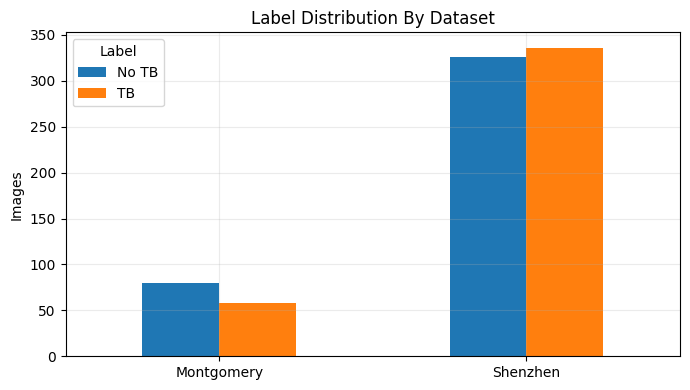

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
label_plot = metadata_df.groupby(["Dataset", "label_name"]).size().unstack(fill_value=0)
label_plot = label_plot[[col for col in ["No TB", "TB"] if col in label_plot.columns]]
label_plot.plot(kind="bar", ax=ax, rot=0)
ax.set_title("Label Distribution By Dataset")
ax.set_xlabel("")
ax.set_ylabel("Images")
ax.legend(title="Label")
plt.tight_layout()

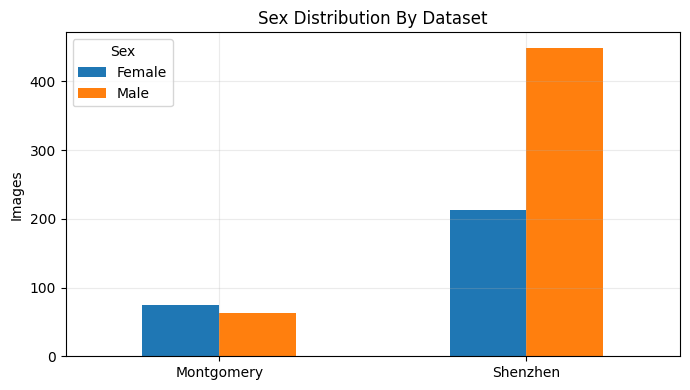

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
sex_plot = metadata_df.groupby(["Dataset", "sex"]).size().unstack(fill_value=0)
sex_plot = sex_plot[[col for col in ["Female", "Male"] if col in sex_plot.columns]]
sex_plot.plot(kind="bar", ax=ax, rot=0)
ax.set_title("Sex Distribution By Dataset")
ax.set_xlabel("")
ax.set_ylabel("Images")
ax.legend(title="Sex")
plt.tight_layout()

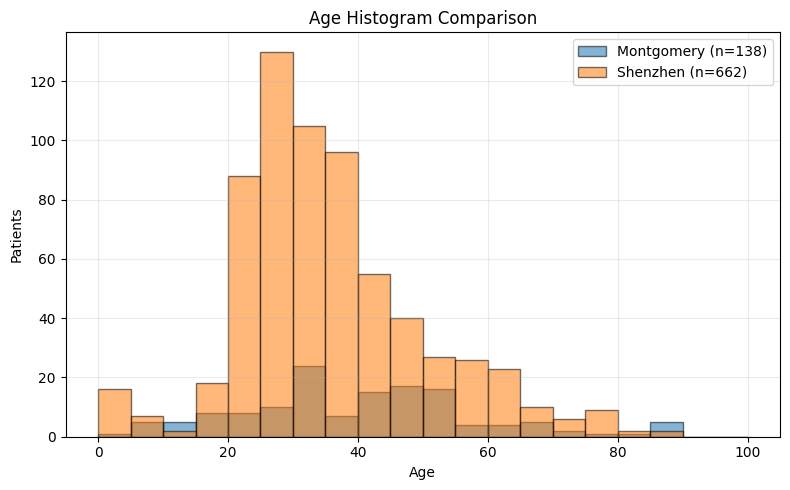

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.arange(0, 101, 5)
for dataset_name, group in metadata_df.dropna(subset=["age"]).groupby("Dataset"):
    ax.hist(group["age"], bins=bins, alpha=0.55, label=f"{dataset_name} (n={len(group)})", edgecolor="black")
ax.set_title("Age Histogram Comparison")
ax.set_xlabel("Age")
ax.set_ylabel("Patients")
ax.legend()
plt.tight_layout()

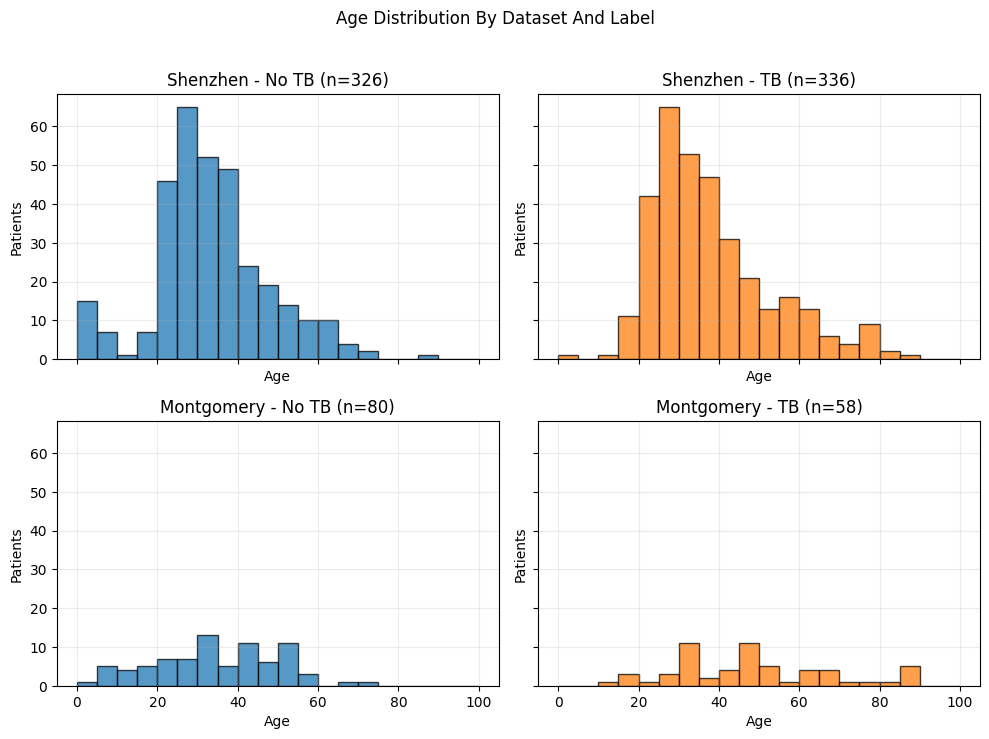

In [10]:
datasets = list(DATASETS.keys())
labels = [label for label in ["No TB", "TB"] if label in metadata_df["label_name"].unique()]
fig, axes = plt.subplots(len(datasets), len(labels), figsize=(5 * len(labels), 3.6 * len(datasets)), sharex=True, sharey=True)
axes = np.array(axes).reshape(len(datasets), len(labels))
bins = np.arange(0, 101, 5)

for row, dataset_name in enumerate(datasets):
    for col, label in enumerate(labels):
        ax = axes[row, col]
        subset = metadata_df[(metadata_df["Dataset"] == dataset_name) & (metadata_df["label_name"] == label)].dropna(subset=["age"])
        ax.hist(subset["age"], bins=bins, color="tab:blue" if label == "No TB" else "tab:orange", alpha=0.75, edgecolor="black")
        ax.set_title(f"{dataset_name} - {label} (n={len(subset)})")
        ax.set_xlabel("Age")
        ax.set_ylabel("Patients")

plt.suptitle("Age Distribution By Dataset And Label", y=1.02)
plt.tight_layout()

## 4. Pixel Intensity Histogram

Aggregate raw grayscale pixel intensities for each dataset using `cv2.IMREAD_GRAYSCALE`, matching the image-read path used by the classification notebook.

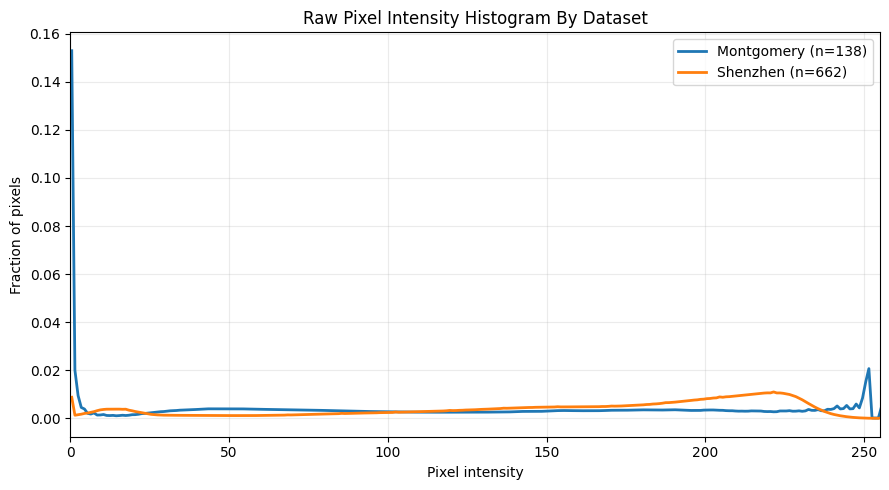

In [11]:
def aggregate_pixel_histogram(image_paths, bins: int = 256) -> tuple[np.ndarray, np.ndarray]:
    edges = np.arange(bins + 1)
    counts = np.zeros(bins, dtype=np.float64)
    total_pixels = 0

    for image_path in image_paths:
        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise FileNotFoundError(image_path)
        hist, _ = np.histogram(image.ravel(), bins=edges)
        counts += hist
        total_pixels += image.size

    density = counts / max(1, total_pixels)
    centers = (edges[:-1] + edges[1:]) / 2
    return centers, density


fig, ax = plt.subplots(figsize=(9, 5))
for dataset_name, group in metadata_df.groupby("Dataset"):
    centers, density = aggregate_pixel_histogram(group["image_path"])
    ax.plot(centers, density, linewidth=2, label=f"{dataset_name} (n={len(group)})")

ax.set_title("Raw Pixel Intensity Histogram By Dataset")
ax.set_xlabel("Pixel intensity")
ax.set_ylabel("Fraction of pixels")
ax.set_xlim(0, 255)
ax.legend()
plt.tight_layout()

## 5. Classification Normalization Shift

Match the TB classification notebook preprocessing: per-image percentile scaling, resize to the classifier input size, then standardize every split with mean and std calculated only from the Shenzhen training split. Montgomery is shown as the external validation distribution after using those Shenzhen train statistics.

In [12]:
CLASSIFICATION_SEED = 42
CLASSIFICATION_IMAGE_SIZE = 384


def stratified_image_split(df: pd.DataFrame, valid_fraction: float = 0.2, seed: int = CLASSIFICATION_SEED):
    rng = np.random.default_rng(seed)
    train_ids, valid_ids = [], []
    for _, group in df.groupby("label"):
        ids = group["ImageId"].to_numpy().copy()
        rng.shuffle(ids)
        n_valid = max(1, int(round(len(ids) * valid_fraction)))
        valid_ids.extend(ids[:n_valid])
        train_ids.extend(ids[n_valid:])
    train_ids = np.array(train_ids)
    valid_ids = np.array(valid_ids)
    rng.shuffle(train_ids)
    rng.shuffle(valid_ids)
    return train_ids, valid_ids


def read_grayscale_png(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(path)
    return image


def normalize_percentile(image: np.ndarray, lower: float = 1, upper: float = 99, eps: float = 1e-7) -> np.ndarray:
    image = image.astype(np.float32)
    lo, hi = np.percentile(image, [lower, upper])
    image = np.clip(image, lo, hi)
    return ((image - lo) / (hi - lo + eps)).astype(np.float32)


def classification_preprocess_image(image_path: Path, size: int = CLASSIFICATION_IMAGE_SIZE) -> np.ndarray:
    image = normalize_percentile(read_grayscale_png(image_path))
    return cv2.resize(image, (size, size), interpolation=cv2.INTER_LINEAR).astype(np.float32)


def image_stats(image_paths) -> tuple[float, float]:
    pixel_sum = 0.0
    pixel_squared_sum = 0.0
    pixel_count = 0

    for image_path in image_paths:
        image = classification_preprocess_image(image_path).astype(np.float64)
        pixel_sum += image.sum()
        pixel_squared_sum += np.square(image).sum()
        pixel_count += image.size

    mean = pixel_sum / max(1, pixel_count)
    variance = max(pixel_squared_sum / max(1, pixel_count) - mean**2, 0.0)
    return float(mean), float(np.sqrt(variance))


def aggregate_preprocessed_histogram(image_paths, bins: np.ndarray, mean: float | None = None, std: float | None = None) -> np.ndarray:
    counts = np.zeros(len(bins) - 1, dtype=np.float64)
    total_pixels = 0

    for image_path in image_paths:
        image = classification_preprocess_image(image_path)
        if mean is not None and std is not None:
            image = (image - mean) / std
        hist, _ = np.histogram(image.ravel(), bins=bins)
        counts += hist
        total_pixels += image.size

    return counts / max(1, total_pixels)


shenzhen_df = metadata_df[metadata_df["Dataset"] == "Shenzhen"].copy()
montgomery_df = metadata_df[metadata_df["Dataset"] == "Montgomery"].copy()
train_ids, valid_ids = stratified_image_split(shenzhen_df)

split_frames = [
    shenzhen_df[shenzhen_df["ImageId"].isin(train_ids)].assign(split="shenzhen_train"),
    shenzhen_df[shenzhen_df["ImageId"].isin(valid_ids)].assign(split="shenzhen_valid"),
    montgomery_df.assign(split="montgomery_external"),
]
classification_split_df = pd.concat(split_frames, ignore_index=True)

train_image_paths = classification_split_df.loc[classification_split_df["split"] == "shenzhen_train", "image_path"]
train_mean, train_std = image_stats(train_image_paths)

normalization_summary = classification_split_df.groupby("split").agg(
    images=("ImageId", "size"),
    tb_fraction=("label", "mean"),
)
normalization_summary["mean_used"] = train_mean
normalization_summary["std_used"] = train_std
normalization_summary

,images,tb_fraction,mean_used,std_used
split,,,,
montgomery_external,138,0.420290,0.653927,0.285021
shenzhen_train,530,0.507547,0.653927,0.285021
shenzhen_valid,132,0.507576,0.653927,0.285021


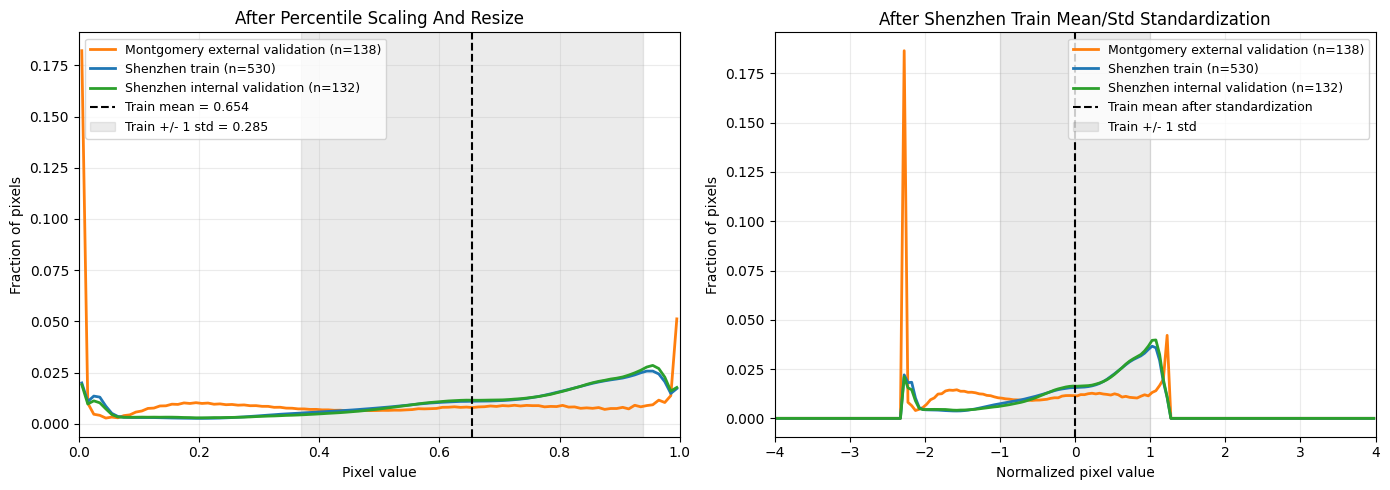

In [13]:
raw_bins = np.linspace(0, 1, 101)
raw_centers = (raw_bins[:-1] + raw_bins[1:]) / 2
normalized_bins = np.linspace(-4, 4, 161)
normalized_centers = (normalized_bins[:-1] + normalized_bins[1:]) / 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {
    "shenzhen_train": "tab:blue",
    "shenzhen_valid": "tab:green",
    "montgomery_external": "tab:orange",
}
labels = {
    "shenzhen_train": "Shenzhen train",
    "shenzhen_valid": "Shenzhen internal validation",
    "montgomery_external": "Montgomery external validation",
}

for split_name, group in classification_split_df.groupby("split"):
    raw_density = aggregate_preprocessed_histogram(group["image_path"], raw_bins)
    normalized_density = aggregate_preprocessed_histogram(group["image_path"], normalized_bins, mean=train_mean, std=train_std)

    axes[0].plot(raw_centers, raw_density, linewidth=2, color=colors[split_name], label=f"{labels[split_name]} (n={len(group)})")
    axes[1].plot(normalized_centers, normalized_density, linewidth=2, color=colors[split_name], label=f"{labels[split_name]} (n={len(group)})")

axes[0].axvline(train_mean, color="black", linestyle="--", linewidth=1.5, label=f"Train mean = {train_mean:.3f}")
axes[0].axvspan(train_mean - train_std, train_mean + train_std, color="black", alpha=0.08, label=f"Train +/- 1 std = {train_std:.3f}")
axes[0].set_title("After Percentile Scaling And Resize")
axes[0].set_xlabel("Pixel value")
axes[0].set_ylabel("Fraction of pixels")
axes[0].set_xlim(0, 1)

axes[1].axvline(0, color="black", linestyle="--", linewidth=1.5, label="Train mean after standardization")
axes[1].axvspan(-1, 1, color="black", alpha=0.08, label="Train +/- 1 std")
axes[1].set_title("After Shenzhen Train Mean/Std Standardization")
axes[1].set_xlabel("Normalized pixel value")
axes[1].set_ylabel("Fraction of pixels")
axes[1].set_xlim(-4, 4)

for ax in axes:
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

plt.tight_layout()

## 6. Parser Review Samples

If parsed sex or age is missing, use this table to inspect the original first clinical-reading line.

In [14]:
metadata_df.loc[
    metadata_df["sex"].isna() | metadata_df["age"].isna(),
    ["Dataset", "ImageId", "label_name", "sex", "age", "reading_first_line", "reading_path"],
].head(20)

,Dataset,ImageId,label_name,sex,age,reading_first_line,reading_path
